# Simple LSTM Classifier

Train a small LSTM on preprocessed_dataset.pt to predict keyboard characters (classification).
Standalone notebook — no GIK trainer. Uses Focal Loss.

In [50]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import numpy as np

PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from pretraining import load_preprocessed_dataset, get_class_weights
from src.Constants.char_to_key import CHAR_TO_INDEX, NUM_CLASSES, INDEX_TO_CHAR
from ml.models.loss_functions.custom_losses import FocalLoss
from src.visualisation.visualisation import compute_confusion_matrix_40x40, plot_virtual_keyboard_heatmap

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Device: {DEVICE}")

Device: mps


## Config & Load Data

In [51]:
DATA_PATH = "data_hazel_7/processed_dataset.pt"
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15

In [52]:
dataset = load_preprocessed_dataset(
    DATA_PATH,
    char_to_index=CHAR_TO_INDEX,
    is_one_hot_labels=False,
    return_class_id=False,
    add_prev_char=True,
)
print(f"Dataset: {len(dataset)} samples, input_dim={dataset.input_dim}, num_classes={NUM_CLASSES}")

Dataset: 2131 samples, input_dim=122, num_classes=40


In [53]:
n = len(dataset)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)
n_test = n - n_train - n_val

train_ds = Subset(dataset, range(0, n_train))
val_ds = Subset(dataset, range(n_train, n_train + n_val))
test_ds = Subset(dataset, range(n_train + n_val, n))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 1491, Val: 319, Test: 321


## Simple LSTM Model

Acts directly on (T, D): LSTM input_size=D (features per timestep). No projection.

In [54]:
class SimpleLSTMClassifier(nn.Module):
    """LSTM acting directly on (T, D). No projection: input_size=D (features per timestep)."""
    def __init__(self, input_dim: int, num_classes: int = 40, hidden_dim: int = 64, num_layers: int = 1, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (B, T, D)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])  # (B, num_classes)

## Train

In [55]:
class_weights = get_class_weights(DATA_PATH, train_ratio=0.8, split_strategy="contiguous").to(DEVICE)
criterion = FocalLoss(gamma=2.0, alpha=class_weights)
model = SimpleLSTMClassifier(input_dim=dataset.input_dim, num_classes=NUM_CLASSES, hidden_dim=64, num_layers=1, dropout=0.2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

## Model Architecture

In [56]:
print(model)
print("\n" + "=" * 60)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleLSTMClassifier(
  (lstm): LSTM(122, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=40, bias=True)
)

Parameters: 50,728


In [57]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        x, y = [b.to(device) for b in batch]
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            x, y = [b.to(device) for b in batch]
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            pred = logits.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return total_loss / total if total else 0.0, correct / total if total else 0.0

In [58]:
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")

Epoch   1 | Train loss: 3.0049 | Val loss: 2.7250 | Val acc: 0.0940
Epoch  10 | Train loss: 1.1201 | Val loss: 2.6935 | Val acc: 0.1411
Epoch  20 | Train loss: 0.3346 | Val loss: 2.9405 | Val acc: 0.1944
Epoch  30 | Train loss: 0.1103 | Val loss: 3.3119 | Val acc: 0.2069
Epoch  40 | Train loss: 0.0466 | Val loss: 3.5557 | Val acc: 0.2288
Epoch  50 | Train loss: 0.0259 | Val loss: 3.7938 | Val acc: 0.2194
Epoch  60 | Train loss: 0.0597 | Val loss: 3.2659 | Val acc: 0.2382
Epoch  70 | Train loss: 0.0184 | Val loss: 3.5778 | Val acc: 0.2476
Epoch  80 | Train loss: 0.0099 | Val loss: 3.6777 | Val acc: 0.2539
Epoch  90 | Train loss: 0.0060 | Val loss: 3.7787 | Val acc: 0.2476
Epoch 100 | Train loss: 0.0039 | Val loss: 3.8376 | Val acc: 0.2508


## Results

In [59]:
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)

print("=" * 60)
print("Simple LSTM Classifier Results (Focal Loss)")
print("=" * 60)
print(f"Focal Loss (gamma=2.0):")
print(f"  Val loss:  {history['val_loss'][-1]:.4f}")
print(f"  Test loss: {test_loss:.4f}")
print(f"Character accuracy:")
print(f"  Val acc:  {history['val_acc'][-1]:.4f} ({history['val_acc'][-1]*100:.2f}%)")
print(f"  Test acc: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("=" * 60)

Simple LSTM Classifier Results (Focal Loss)
Focal Loss (gamma=2.0):
  Val loss:  3.8376
  Test loss: 4.5311
Character accuracy:
  Val acc:  0.2508 (25.08%)
  Test acc: 0.3022 (30.22%)


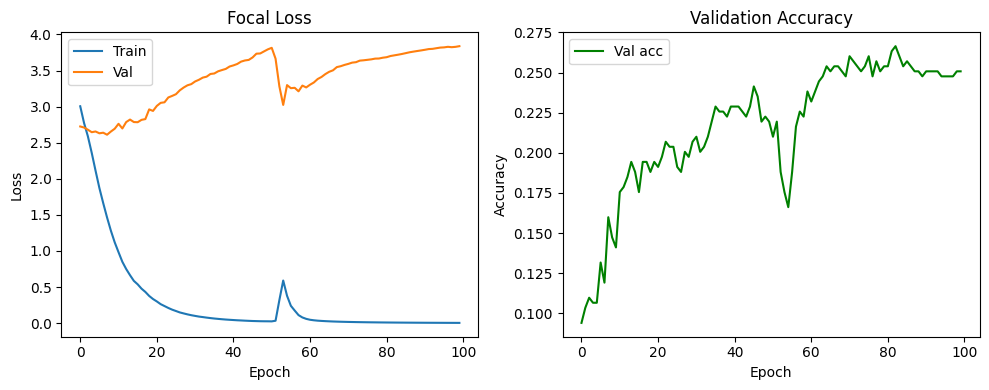

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Focal Loss")
axes[1].plot(history["val_acc"], label="Val acc", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Validation Accuracy")
plt.tight_layout()
plt.show()

## Keyboard Heatmap

Confusion heatmaps for selected anchor characters: where the model predicts when the true character is the anchor.

In [61]:
cm_test = compute_confusion_matrix_40x40(test_ds, model, DEVICE, coord_dict=None)

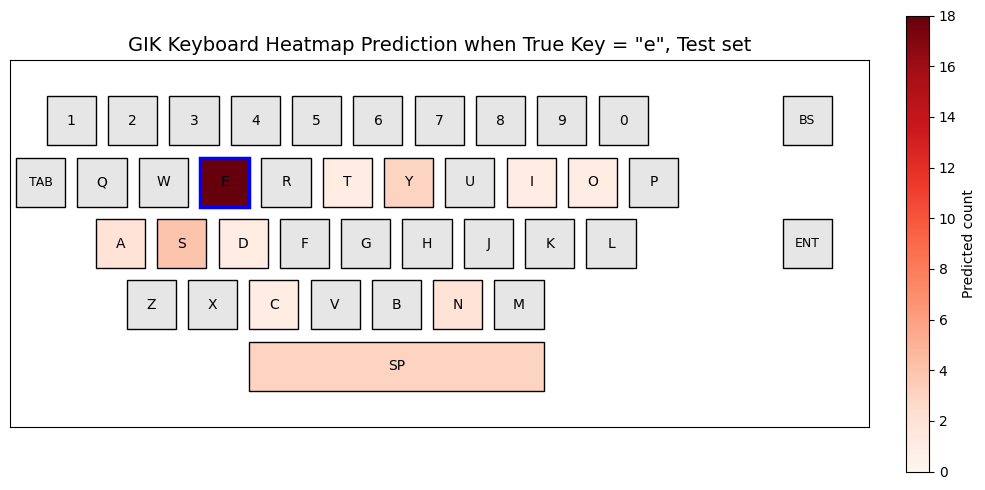

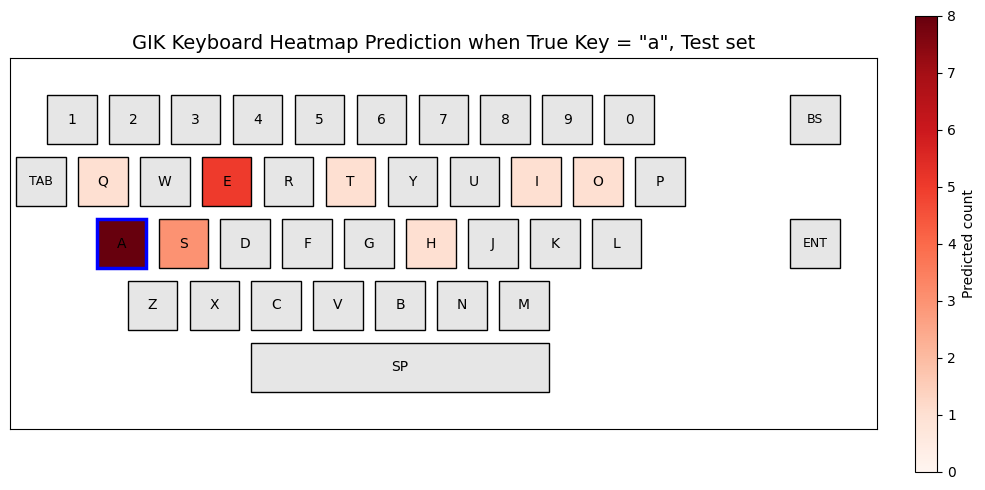

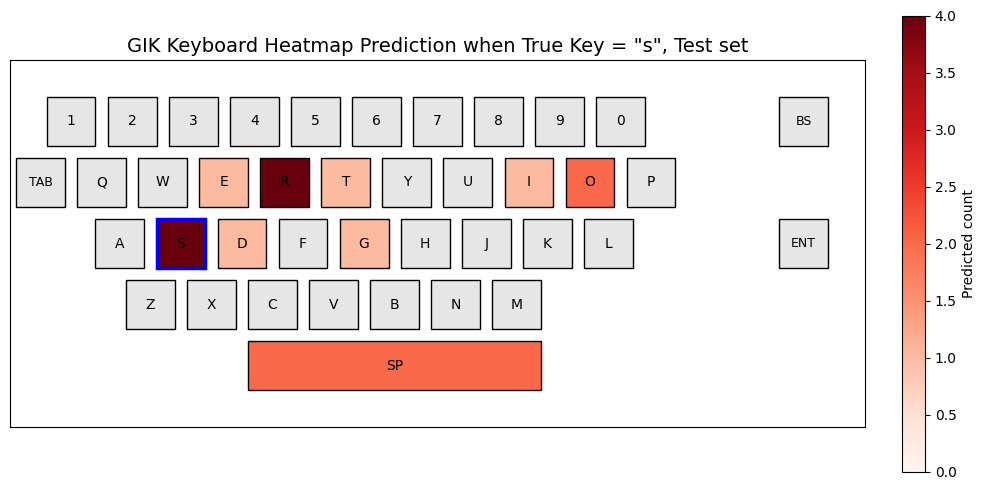

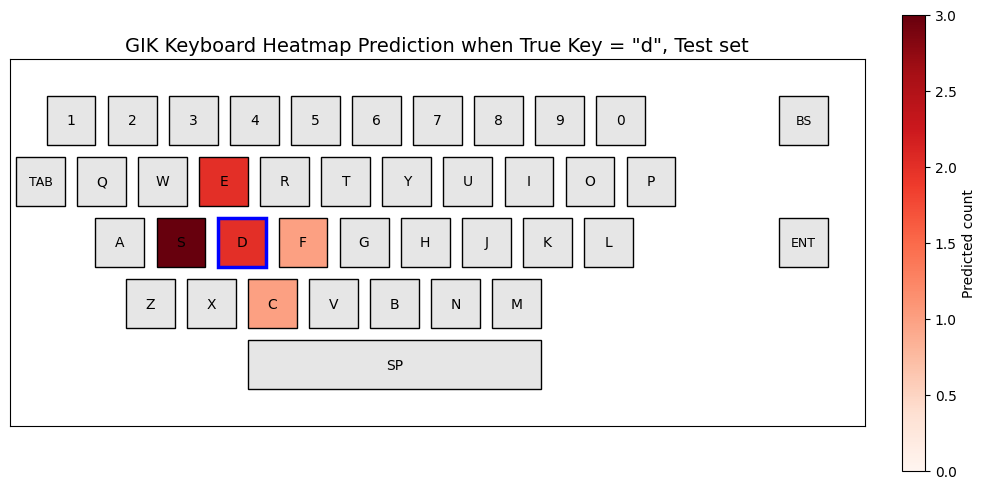

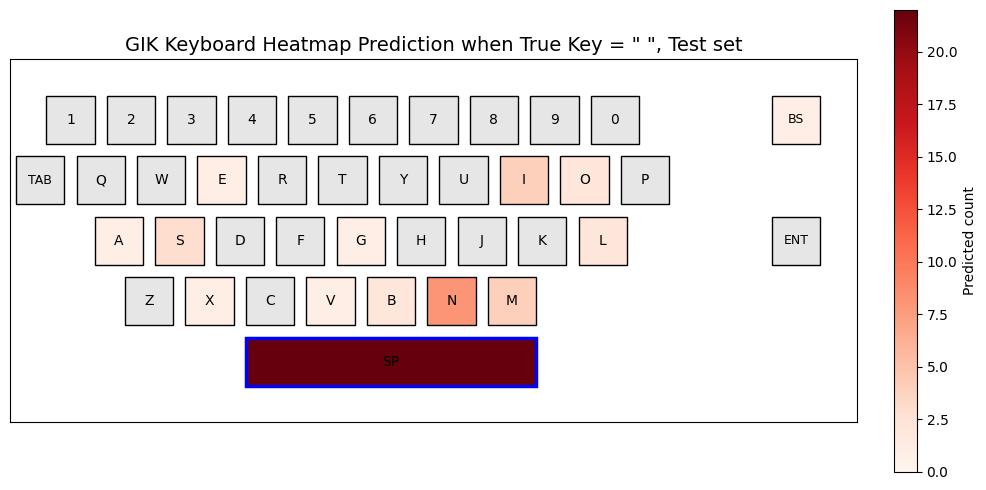

In [62]:
# Heatmaps for a few anchor characters
for anchor in ['e', 'a', 's', 'd', ' ']:
    plot_virtual_keyboard_heatmap(cm_test, anchor, 'Test')